# Embedding Neighbor Correlation

Core validation question: **do companies that are nearest neighbours in embedding space
have more correlated future financial trajectories than companies that are nearest
neighbours in raw financial space, or than random contemporaries?**

If yes, the embedding is a better *comparables finder* than raw accounting data —
a directly useful property for fundamental analysts.

**Protocol**
- For each of the 52 quarters, find every company's k=5 nearest neighbours in:
  - Embedding space (z, 80-dim)
  - Financial space (mean-pooled X_fin, 40-dim)
  - Random (k=5 randomly sampled contemporaries as baseline)
- For each (anchor, neighbour) pair, compute Pearson r of their aggregate financial
  signal over the next L=6 quarters
- Compare the three correlation distributions with a Mann-Whitney U test

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, mannwhitneyu
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

pd.set_option('display.float_format', '{:.4f}'.format)

ROOT           = Path('../')
PREPROCESS_DIR = ROOT / 'data' / 'out' / 'preprocess'
META_DIR       = ROOT / 'data' / 'in'
MODEL_PATH     = ROOT / 'runs' / 'tin20-tout4-latent80_ctx.pth'

T_IN   = 20
T_OUT  = 4
K      = 5    # neighbours per anchor
L      = 6    # future quarters for trajectory correlation
NORM_MODE = 'global'
DEVICE    = torch.device('cpu')

## 1. Load & pre-process data

In [2]:
from services.data import load_raw_data, filter_columns, ColumnFilter
from services.transforms import symmetric_log

bs_df, is_df, cf_df, macro_df, _ = load_raw_data(
    PREPROCESS_DIR, META_DIR, norm_mode=NORM_MODE
)
bs_f, is_f, cf_f, macro_f = filter_columns(
    bs_df, is_df, cf_df, macro_df, cond=ColumnFilter.DIFF_Y
)
print('Data loaded.')

Data loaded.


## 2. Build sliding windows

In [3]:
def build_window_dataset(bs_f, is_f, cf_f, macro_f, T_in):
    df = (
        bs_f.merge(is_f, on=['ticker', 'quarter'])
            .merge(cf_f, on=['ticker', 'quarter'])
            .merge(macro_f, on='quarter')
            .sort_values(['ticker', 'quarter'])
    )
    macro_cols = [c for c in macro_f.columns if c != 'quarter']
    fin_cols   = [c for c in df.columns if c not in ['ticker', 'quarter'] + macro_cols]

    X_fin_list, X_mac_list, meta = [], [], []
    for ticker, g in df.groupby('ticker'):
        if len(g) < T_in:
            continue
        f = g[fin_cols].values.astype(np.float32)
        m = g[macro_cols].values.astype(np.float32)
        q = g['quarter'].values
        for i in range(len(g) - T_in + 1):
            X_fin_list.append(f[i : i + T_in])
            X_mac_list.append(m[i : i + T_in])
            meta.append({'ticker': ticker, 'end_quarter': q[i + T_in - 1]})

    return (
        torch.tensor(np.stack(X_fin_list)),
        torch.tensor(np.stack(X_mac_list)),
        pd.DataFrame(meta),
        fin_cols, macro_cols,
    )


X_fin_raw, X_mac_raw, meta_df, fin_cols, macro_cols = build_window_dataset(
    bs_f, is_f, cf_f, macro_f, T_IN
)
print(f'Windows: {len(meta_df):,}  |  companies: {meta_df["ticker"].nunique()}')

Windows: 65,627  |  companies: 2263


## 3. Transforms

In [4]:
from xgboost import XGBRegressor

def _sym_log_np(x):
    return np.sign(x) * np.log1p(np.abs(x))

def compute_company_macro_weights(bs_f, is_f, cf_f, macro_f, fin_cols, macro_cols):
    df = (
        bs_f.merge(is_f, on=['ticker', 'quarter'])
            .merge(cf_f, on=['ticker', 'quarter'])
            .merge(macro_f, on='quarter')
            .sort_values(['ticker', 'quarter'])
    )
    weights = {}
    for ticker, g in df.groupby('ticker'):
        f    = _sym_log_np(g[fin_cols].values.astype(np.float64))
        m    = _sym_log_np(g[macro_cols].values.astype(np.float64))
        sig  = f.mean(axis=1)
        if np.std(sig) < 1e-8 or len(sig) < 5:
            weights[ticker] = np.ones(len(macro_cols), dtype=np.float32)
            continue
        imp   = XGBRegressor(n_estimators=50, max_depth=3, verbosity=0, random_state=42).fit(m, sig).feature_importances_
        sig_c = sig - sig.mean()
        signs = np.sign(np.array([(sig_c * (m[:, j] - m[:, j].mean())).mean() for j in range(m.shape[1])]))
        signs[signs == 0] = 1
        weights[ticker] = (imp * signs).astype(np.float32)
    return weights

print('Computing macro weights...')
company_weights = compute_company_macro_weights(bs_f, is_f, cf_f, macro_f, fin_cols, macro_cols)
print(f'Done — {len(company_weights)} companies.')

Computing macro weights...
Done — 2263 companies.


In [5]:
X_fin_t = symmetric_log(X_fin_raw)
X_mac_t = symmetric_log(X_mac_raw).clone()

tickers_arr = meta_df['ticker'].values
for idx, ticker in enumerate(tickers_arr):
    w = torch.tensor(company_weights[ticker])
    X_mac_t[idx] = X_mac_t[idx] * w.unsqueeze(0)

print(f'X_fin_t: {X_fin_t.shape}  |  X_mac_t: {X_mac_t.shape}')

X_fin_t: torch.Size([65627, 20, 40])  |  X_mac_t: torch.Size([65627, 20, 7])


## 4. Model inference

In [6]:
from models.autoencoder_dlinear_forecaster import ForecastingAE

F_DIM      = X_fin_t.shape[-1]
M_DIM      = X_mac_t.shape[-1]
LATENT_DIM = 80

model = ForecastingAE(T_IN, T_OUT, F_DIM, M_DIM, LATENT_DIM).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'Loaded — latent: {LATENT_DIM}, F: {F_DIM}, M: {M_DIM}')

BATCH  = 512
Z_list = []
with torch.no_grad():
    for start in range(0, len(X_fin_t), BATCH):
        z, _ = model(X_fin_t[start:start+BATCH].to(DEVICE),
                     X_mac_t[start:start+BATCH].to(DEVICE))
        Z_list.append(z.cpu())
Z = torch.cat(Z_list)
print(f'Embeddings: {Z.shape}')

Loaded — latent: 80, F: 40, M: 7
Embeddings: torch.Size([65627, 80])


## 5. Precompute aggregate financial signal

$s_{c,t} = \frac{1}{F}\sum_f x_{c,t,f}$ — the same aggregate signal used in the macro
weighting step.  This is our proxy for the overall financial trajectory of each company.

In [7]:
# Build full financial panel with aggregate signal per (ticker, quarter)
df_full = (
    bs_f.merge(is_f, on=['ticker', 'quarter'])
        .merge(cf_f, on=['ticker', 'quarter'])
        .sort_values(['ticker', 'quarter'])
)
feat_cols = [c for c in df_full.columns if c not in ['ticker', 'quarter']]
df_full['s'] = df_full[feat_cols].mean(axis=1)

signal_lookup = df_full.set_index(['ticker', 'quarter'])['s'].to_dict()

# Quarter ↔ index mapping
all_quarters = sorted(df_full['quarter'].unique())
q_to_idx     = {q: i for i, q in enumerate(all_quarters)}
idx_to_q     = {i: q for q, i in q_to_idx.items()}

print(f'Signal lookup: {len(signal_lookup):,} (ticker, quarter) entries')
print(f'Quarter range: {all_quarters[0]} → {all_quarters[-1]}')


def future_trajectory(ticker: str, end_quarter: str, L: int = L):
    """Return the next L quarters' aggregate financial signal, or None if incomplete."""
    base = q_to_idx.get(end_quarter)
    if base is None:
        return None
    vals = [signal_lookup.get((ticker, idx_to_q.get(base + k))) for k in range(1, L + 1)]
    if any(v is None or (isinstance(v, float) and np.isnan(v)) for v in vals):
        return None
    return np.array(vals, dtype=np.float32)

Signal lookup: 108,624 (ticker, quarter) entries
Quarter range: 2013Q1 → 2024Q4


## 6. Neighbour correlation experiment

For each end-quarter, build the cosine similarity matrix in embedding and financial
space, pick the top-k neighbours for every company, and record the Pearson correlation
of their future L-quarter financial trajectories.

In [ ]:
import warnings
from scipy.stats import ConstantInputWarning

rng = np.random.default_rng(42)

meta_df_reset = meta_df.reset_index(drop=True)
records = []

# Only keep quarters for which all L future quarters exist in signal_lookup
all_valid_quarters = set(
    q for q in all_quarters
    if all((q_to_idx[q] + k) in idx_to_q for k in range(1, L + 1))
)
quarters = sorted(q for q in meta_df_reset['end_quarter'].unique()
                  if q in all_valid_quarters)
print(f'Effective quarters (with L={L} future data): {len(quarters)}  ({quarters[0]} → {quarters[-1]})')

for qi, q in enumerate(quarters):
    if qi % 5 == 0:
        print(f'  {qi+1}/{len(quarters)} ({q})  pairs so far: {len(records):,}', end='\r')

    grp = meta_df_reset[meta_df_reset['end_quarter'] == q]
    if len(grp) < K + 2:
        continue

    row_indices = grp.index.values
    ticker_list = grp['ticker'].values
    n           = len(grp)

    emb_q = Z[row_indices].numpy()
    fin_q = X_fin_t[row_indices].mean(dim=1).numpy()

    sim_emb = cosine_similarity(emb_q)
    sim_fin = cosine_similarity(fin_q)
    np.fill_diagonal(sim_emb, -np.inf)
    np.fill_diagonal(sim_fin, -np.inf)

    futures = {ticker_list[i]: future_trajectory(ticker_list[i], q) for i in range(n)}

    for i in range(n):
        anchor_ticker = ticker_list[i]
        anchor_future = futures[anchor_ticker]
        if anchor_future is None or np.std(anchor_future) < 1e-8:
            continue

        emb_neighbors  = np.argsort(sim_emb[i])[::-1][:K]
        fin_neighbors  = np.argsort(sim_fin[i])[::-1][:K]
        all_j          = [j for j in range(n) if j != i]
        rand_neighbors = rng.choice(all_j, size=K, replace=False)

        for neighbor_set, label in [
            (emb_neighbors,  'Embedding'),
            (fin_neighbors,  'Financial'),
            (rand_neighbors, 'Random'),
        ]:
            for j in neighbor_set:
                peer_future = futures[ticker_list[j]]
                if peer_future is None or np.std(peer_future) < 1e-8:
                    continue
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore', ConstantInputWarning)
                    r, _ = pearsonr(anchor_future, peer_future)
                if not np.isnan(r):
                    records.append({'type': label, 'r': r, 'quarter': q})

results_df = pd.DataFrame(records)
print(f'\nTotal pairs collected: {len(results_df):,}')
print(results_df.groupby('type')['r'].describe().round(3))

## 7. Statistical test

In [9]:
emb_r  = results_df.loc[results_df['type'] == 'Embedding',  'r'].values
fin_r  = results_df.loc[results_df['type'] == 'Financial',  'r'].values
rand_r = results_df.loc[results_df['type'] == 'Random',     'r'].values

stat_ef, p_ef = mannwhitneyu(emb_r, fin_r,  alternative='greater')
stat_er, p_er = mannwhitneyu(emb_r, rand_r, alternative='greater')
stat_fr, p_fr = mannwhitneyu(fin_r, rand_r, alternative='greater')

print('Mann-Whitney U (one-sided: row > col):')
print(f'  Embedding > Financial  : U={stat_ef:.0f},  p={p_ef:.4f}')
print(f'  Embedding > Random     : U={stat_er:.0f},  p={p_er:.4f}')
print(f'  Financial > Random     : U={stat_fr:.0f},  p={p_fr:.4f}')
print()
print('Mean Pearson r by neighbour type:')
for label in ['Embedding', 'Financial', 'Random']:
    sub = results_df[results_df['type'] == label]['r']
    print(f'  {label:<12}: {sub.mean():.4f}  (median {sub.median():.4f})')

Mann-Whitney U (one-sided: row > col):
  Embedding > Financial  : U=35657274668,  p=0.0000
  Embedding > Random     : U=41579364117,  p=0.0000
  Financial > Random     : U=39376242354,  p=0.0000

Mean Pearson r by neighbour type:
  Embedding   : 0.2435  (median 0.2926)
  Financial   : 0.1865  (median 0.2043)
  Random      : 0.0291  (median 0.0379)


## 8. Visualisation

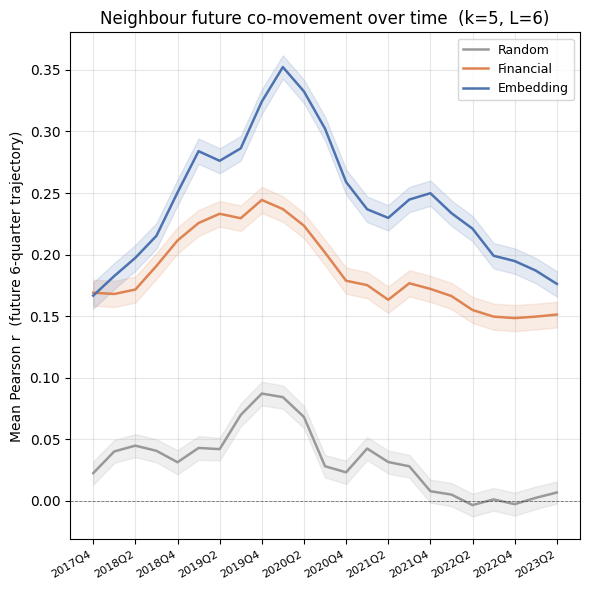

In [21]:
order  = ['Random', 'Financial', 'Embedding']
colors = {'Random': '#999999', 'Financial': '#DD8452', 'Embedding': '#4C72B0'}

fig, ax = plt.subplots(figsize=(6, 6))

for t in order:
    qstats = results_df[results_df['type'] == t].groupby('quarter')['r'].agg(['mean', 'sem'])
    xs = range(len(qstats))
    ax.plot(xs, qstats['mean'], label=t, color=colors[t], linewidth=1.8)
    ax.fill_between(xs,
                    qstats['mean'] - 1.96 * qstats['sem'],
                    qstats['mean'] + 1.96 * qstats['sem'],
                    alpha=0.15, color=colors[t])

step = max(1, len(qstats) // 8)
ax.set_xticks(range(0, len(qstats), step))
ax.set_xticklabels(qstats.index[::step], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Mean Pearson r  (future 6-quarter trajectory)')
ax.set_title(f'Neighbour future co-movement over time  (k={K}, L={L})')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Formal definition

Let $\mathcal{Q}$ be the set of observed quarters and $\mathcal{C}_q$ the set of companies whose sliding window ends at quarter $q$. For each company $c \in \mathcal{C}_q$ we have two representations derived from its window:

$$\mathbf{z}_c^q \in \mathbb{R}^D, \qquad \bar{\mathbf{x}}_c^q = \frac{1}{T_{\mathrm{in}}}\sum_{t=1}^{T_{\mathrm{in}}} \mathbf{x}_{c,t}^q \in \mathbb{R}^F$$

where $\mathbf{z}_c^q$ is the latent embedding from the ForecastingAE and $\bar{\mathbf{x}}_c^q$ is the time-averaged raw financial representation. For each anchor $c$, define its $k$-nearest neighbours under cosine similarity in each space:

$$\mathcal{N}_k^{\star}(c,q) = \underset{\substack{S \subseteq \mathcal{C}_q \setminus \{c\} \\ |S|=k}}{\arg\max} \sum_{c' \in S} \frac{(\mathbf{r}_c^{q})^\top \mathbf{r}_{c'}^{q}}{\|\mathbf{r}_c^{q}\|\,\|\mathbf{r}_{c'}^{q}\|}, \qquad \star \in \{\mathrm{emb},\, \mathrm{fin}\}$$

where $\mathbf{r}^q_c = \mathbf{z}^q_c$ for $\star = \mathrm{emb}$ and $\mathbf{r}^q_c = \bar{\mathbf{x}}^q_c$ for $\star = \mathrm{fin}$. A random baseline $\mathcal{N}_k^{\mathrm{rand}}(c,q)$ draws $k$ companies uniformly from $\mathcal{C}_q \setminus \{c\}$.

The aggregate financial signal of company $c$ at quarter $t$ is:

$$s_{c,t} = \frac{1}{F}\sum_{f=1}^{F} x_{c,t,f}$$

yielding the $L$-quarter future trajectory $\mathbf{s}_c^{q} = (s_{c,q+1},\ldots,s_{c,q+L}) \in \mathbb{R}^L$. For each anchor–neighbour pair $(c,\, c')$ at quarter $q$ we compute:

$$\rho^\star(c, c', q) = \mathrm{Corr}\!\left(\mathbf{s}_c^{q},\, \mathbf{s}_{c'}^{q}\right), \qquad c' \in \mathcal{N}_k^{\star}(c,q)$$

We then test whether embedding neighbours exhibit higher future co-movement than financial or random neighbours:

$$\mathbb{E}\!\left[\rho^{\mathrm{emb}}\right] > \mathbb{E}\!\left[\rho^{\mathrm{fin}}\right] > \mathbb{E}\!\left[\rho^{\mathrm{rand}}\right]$$

with significance assessed via a one-sided Mann–Whitney $U$ test across all $(c, c', q)$ triples. With $k=5$, $L=6$, and $|\mathcal{Q}|=29$ quarters the three distributions each contain approximately 260,000 pairs.

## 10. Summary

In [11]:
print('=' * 60)
print('NEIGHBOUR CORRELATION SUMMARY')
print('=' * 60)
print(f'Quarters       : {len(quarters)}')
print(f'k neighbours   : {K}  |  future horizon L: {L} quarters')
print(f'Total pairs    : {len(results_df):,}')
print()
for label in ['Embedding', 'Financial', 'Random']:
    sub = results_df[results_df['type'] == label]['r']
    print(f'{label:<12}: mean r = {sub.mean():.4f}  median = {sub.median():.4f}  n = {len(sub):,}')
print()
print('Statistical tests (Mann-Whitney U, one-sided):')
print(f'  Embedding > Financial : p = {p_ef:.4f}  {"✓" if p_ef < 0.05 else "✗"}')
print(f'  Embedding > Random    : p = {p_er:.4f}  {"✓" if p_er < 0.05 else "✗"}')
print(f'  Financial > Random    : p = {p_fr:.4f}  {"✓" if p_fr < 0.05 else "✗"}')

NEIGHBOUR CORRELATION SUMMARY
Quarters       : 29
k neighbours   : 5  |  future horizon L: 6 quarters
Total pairs    : 779,868

Embedding   : mean r = 0.2435  median = 0.2926  n = 259,922
Financial   : mean r = 0.1865  median = 0.2043  n = 259,887
Random      : mean r = 0.0291  median = 0.0379  n = 260,059

Statistical tests (Mann-Whitney U, one-sided):
  Embedding > Financial : p = 0.0000  ✓
  Embedding > Random    : p = 0.0000  ✓
  Financial > Random    : p = 0.0000  ✓
